# Draft Mirror — Final Submission
## Multi-label Emotion Classification on GoEmotions

**Course:** DM1590 — Machine Learning for Media Technology
**Team:** Fuad, Jamie, Axina (+1)
**Date:** May 19, 2025

---

### Project overview

Draft Mirror predicts the emotional tone of short text comments across 7 Ekman emotion categories (anger, disgust, fear, joy, sadness, surprise, neutral). It uses the GoEmotions dataset (58k Reddit comments, originally labeled with 28 fine-grained emotions, collapsed to the 7-category Ekman taxonomy).

### Pipeline at a glance

```
GoEmotions (28 labels) → Ekman remap (7 multi-label) → Text preprocessing
                                                              │
                            ┌─────────────────────────────────┴──────────────────────┐
                            │                                                        │
                       TF-IDF (1-2 grams)                                            │
                            │                                                        │
                    ┌───────┴────────┐                                  ┌────────────┴───────────┐
                    │                │                                  │                        │
              Naive Bayes      Logistic Regression                 TruncatedSVD            (visualization)
            (course method)   (new method, balanced)                     │                        │
                    │                │                              ┌────┴────┐                   │
                    └────────┬───────┘                          K-means    DBSCAN              t-SNE
                             │                                  (course)   (new)
                       Evaluation
                  (PR curves, error analysis,
                   stratification, demo)
```

### Notebook structure

| Section | Rubric criterion |
|---|---|
| 1. Data preparation | — |
| 2. Supervised: NB + LogReg (with hyperparameter tuning) | Supervised ML application |
| 3. Unsupervised: K-Means + DBSCAN (with t-SNE viz) | Unsupervised ML application |
| 4. Evaluation: metrics, PR curves, confusion matrices, error analysis, stratification | Evaluation |
| 5. Inline interpretability demo | Application + presentation |
| 6. Final summary table | Presentation |


## 0. Setup

Imports, paths, and reproducibility setup.

In [1]:
from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, multilabel_confusion_matrix,
    hamming_loss, precision_recall_curve, average_precision_score,
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score
)

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

if (Path("..") / "data").exists():
    ROOT = Path("..")
else:
    ROOT = Path(".")

PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR    = ROOT / "data" / "models"
FIGURE_DIR    = ROOT / "report" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Consistent styling for all figures
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("ROOT:", ROOT.resolve())
print("Figures will go to:", FIGURE_DIR.resolve())

ROOT: /Users/fammad/Desktop/DM1590-Machine Learning for Media Technology/EmotionRadar
Figures will go to: /Users/fammad/Desktop/DM1590-Machine Learning for Media Technology/EmotionRadar/report/figures


---
## 1. Data Preparation

### What this section does
- Loads GoEmotions from HuggingFace (or pre-saved CSVs)
- Maps the 28 fine-grained emotion labels to the 7 Ekman categories
- Multi-label encoding (a single comment can have multiple emotions)
- Visualizes the class distribution

### Why the Ekman taxonomy?
GoEmotions ships with 28 emotions, but many are semantically close (e.g., *joy*, *amusement*, *excitement*, *pride*, *relief* all express positive affect). The Ekman taxonomy collapses these into 7 cross-culturally validated basic emotions, which gives us more training samples per class and clearer interpretation.

In [2]:
# Try loading pre-saved CSVs first; fall back to HuggingFace if missing
csv_paths = [PROCESSED_DIR / f"{split}.csv" for split in ["train", "val", "test"]]

if all(p.exists() for p in csv_paths):
    train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
    val_df   = pd.read_csv(PROCESSED_DIR / "val.csv")
    test_df  = pd.read_csv(PROCESSED_DIR / "test.csv")
    print("Loaded pre-saved CSVs from", PROCESSED_DIR.resolve())
else:
    from datasets import load_dataset
    dataset = load_dataset("go_emotions", "simplified")
    label_names_raw = dataset["train"].features["labels"].feature.names
    label_to_idx = {n: i for i, n in enumerate(label_names_raw)}

    ekman_mapping = {
        "anger":    ["anger", "annoyance", "disapproval"],
        "disgust":  ["disgust"],
        "fear":     ["fear", "nervousness"],
        "joy":      ["joy", "amusement", "approval", "excitement", "gratitude",
                     "love", "optimism", "relief", "pride", "admiration",
                     "desire", "caring"],
        "sadness":  ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
        "surprise": ["surprise", "realization", "confusion", "curiosity"],
        "neutral":  ["neutral"],
    }

    def build_ekman_df(split_df):
        df = pd.DataFrame({"text": split_df["text"]})
        for ekman_label, sources in ekman_mapping.items():
            src_idx = [label_to_idx[s] for s in sources]
            df[ekman_label] = split_df["labels"].apply(
                lambda lst: int(any(i in lst for i in src_idx))
            )
        return df

    train_df = build_ekman_df(dataset["train"].to_pandas())
    val_df   = build_ekman_df(dataset["validation"].to_pandas())
    test_df  = build_ekman_df(dataset["test"].to_pandas())

    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
    val_df.to_csv(PROCESSED_DIR / "val.csv", index=False)
    test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)
    print("Built CSVs from HuggingFace and saved to", PROCESSED_DIR.resolve())

print(f"\nTrain: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")
train_df.head(3)

Loaded pre-saved CSVs from /Users/fammad/Desktop/DM1590-Machine Learning for Media Technology/EmotionRadar/data/processed

Train: (43410, 8) | Val: (5426, 8) | Test: (5427, 8)


,text,anger,disgust,fear,joy,sadness,surprise,neutral
0,My favourite food is anything I didn't have to...,0,0,0,0,0,0,1
1,"Now if he does off himself, everyone will thin...",0,0,0,0,0,0,1
2,WHY THE FUCK IS BAYLESS ISOING,1,0,0,0,0,0,0


### 1.1 Label distribution

Before any modeling, look at how imbalanced the data is. This drives many later decisions: `class_weight="balanced"` for LogReg, macro-F1 over accuracy, why DBSCAN finds noise, etc.

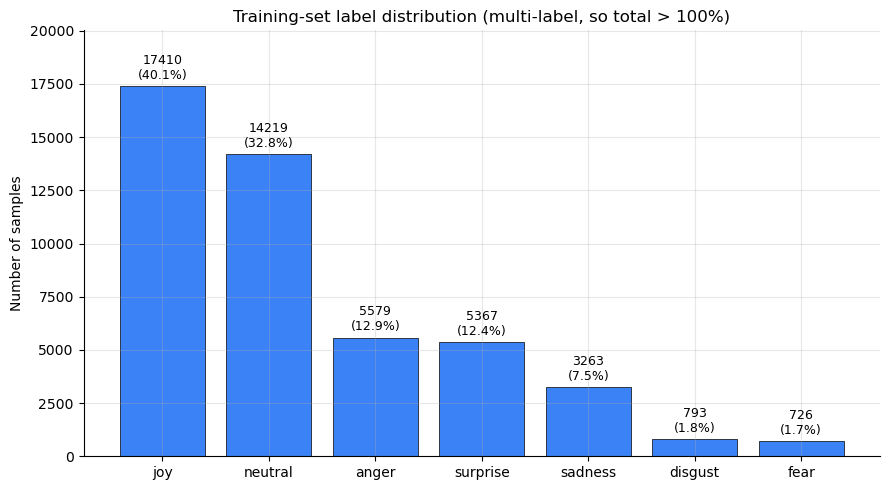


Most frequent emotion (joy): 17410 samples
Least frequent emotion (fear): 726 samples
Imbalance ratio: 24.0×


In [3]:
label_cols = [c for c in train_df.columns if c not in ("text", "cleaned_text")]

# Compute support per class on the full training set
support = train_df[label_cols].sum().sort_values(ascending=False)
support_pct = (support / len(train_df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(support.index, support.values, color="#3b82f6", edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, support_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{int(bar.get_height())}\n({pct}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Training-set label distribution (multi-label, so total > 100%)", fontsize=12)
ax.set_ylabel("Number of samples")
ax.set_ylim(0, support.max() * 1.15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "label_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nMost frequent emotion (joy): {support['joy']} samples")
print(f"Least frequent emotion ({support.index[-1]}): {support.iloc[-1]} samples")
print(f"Imbalance ratio: {support['joy'] / support.iloc[-1]:.1f}×")

**Observation:** The dataset is heavily imbalanced. Joy and neutral together account for ~70% of samples; disgust and fear are <2% each. This means:
- Plain accuracy is misleading (predicting "neutral" all the time would score ~33%).
- We use **macro-F1** (averages F1 across emotions, so rare classes weigh equally).
- LogReg uses `class_weight="balanced"` to compensate.
- The clustering algorithms also struggle here — there's no balanced structure to find.

### 1.2 Text preprocessing

Standard NLP cleaning: lowercase, remove URLs / non-letters, drop short tokens and stopwords, lemmatize. Same function applied to train/val/test.

In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in stop_words and len(t) > 2
    ]
    return " ".join(tokens)

for df in [train_df, val_df, test_df]:
    df["cleaned_text"] = df["text"].apply(preprocess_text)

# Build numpy label arrays once for all downstream sections
y_train = train_df[label_cols].to_numpy()
y_val   = val_df[label_cols].to_numpy()
y_test  = test_df[label_cols].to_numpy()

print("Preprocessing done.")
print("\nExample:")
example = train_df.iloc[2]
print(f"  Original: {example['text']}")
print(f"  Cleaned:  {example['cleaned_text']}")

Preprocessing done.

Example:
  Original: WHY THE FUCK IS BAYLESS ISOING
  Cleaned:  fuck bayless isoing


### 1.3 TF-IDF vectorization

**Why TF-IDF over Sentence-BERT?**
We considered Sentence-BERT for richer embeddings, but TF-IDF has a critical advantage for our use case: its features are individual words, and when combined with a linear classifier (Logistic Regression), the model coefficients tell us exactly *which words* trigger each emotion prediction. This is the basis of the word-level highlighting in the demo at the end.

**Setup:**
- Fit vectorizer on training data only (avoid data leakage)
- Transform val and test using the *same* learned vocabulary
- 5000 features, unigrams + bigrams
- English stopwords filtered (NLTK ones already removed in preprocessing, sklearn provides an additional list)

In [6]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
)
X_train = tfidf_vectorizer.fit_transform(train_df["cleaned_text"])
X_val   = tfidf_vectorizer.transform(val_df["cleaned_text"])
X_test  = tfidf_vectorizer.transform(test_df["cleaned_text"])

print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

Vocabulary size: 5000
X_train: (43410, 5000) | X_val: (5426, 5000) | X_test: (5427, 5000)


---
## 2. Supervised Learning

Two classifiers, both wrapped in `OneVsRestClassifier` to handle the multi-label setting (one binary classifier per emotion).

| Model | Role | Hyperparameter tuned |
|---|---|---|
| Multinomial Naive Bayes | Course method (baseline) | `alpha` (smoothing) |
| Logistic Regression (balanced) | New method beyond the course | `C` (regularization) |

### 2.1 Multinomial Naive Bayes — tune α on validation

`alpha` is additive (Laplace-style) smoothing. We sweep across orders of magnitude on the validation set and pick the best.

In [7]:
alpha_candidates = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0]
val_f1_by_alpha = {}

for alpha in alpha_candidates:
    clf = OneVsRestClassifier(MultinomialNB(alpha=alpha))
    clf.fit(X_train, y_train)
    val_f1_by_alpha[alpha] = f1_score(y_val, clf.predict(X_val), average="macro", zero_division=0)

best_alpha = max(val_f1_by_alpha, key=val_f1_by_alpha.get)

print("Validation macro-F1 by alpha:")
for a, f1 in sorted(val_f1_by_alpha.items()):
    marker = "  <-- selected" if a == best_alpha else ""
    print(f"  alpha={a:>7}  macro-F1={f1:.4f}{marker}")
print(f"\nBest alpha: {best_alpha}")

nb_clf = OneVsRestClassifier(MultinomialNB(alpha=best_alpha))
nb_clf.fit(X_train, y_train)
joblib.dump(nb_clf, MODELS_DIR / "nb_model.pkl")
print("Saved NB model.")

Validation macro-F1 by alpha:
  alpha=  1e-05  macro-F1=0.2491
  alpha= 0.0001  macro-F1=0.2491
  alpha=  0.001  macro-F1=0.2519  <-- selected
  alpha=   0.01  macro-F1=0.2519
  alpha=    0.1  macro-F1=0.2485
  alpha=    1.0  macro-F1=0.1900
  alpha=   10.0  macro-F1=0.0963

Best alpha: 0.001
Saved NB model.


### 2.2 Logistic Regression — tune C on validation

`C` is the inverse of regularization strength (higher C = less regularization). With class weights set to "balanced", LogReg will compensate for the rare classes (disgust, fear). We sweep `C` on the validation set.

In [8]:
C_candidates = [0.1, 0.5, 1.0, 2.0, 5.0]
val_f1_by_C = {}

for C in C_candidates:
    clf = OneVsRestClassifier(
        LogisticRegression(
            class_weight="balanced", max_iter=1000, C=C,
            solver="lbfgs", random_state=RANDOM_STATE
        ),
        n_jobs=-1
    )
    clf.fit(X_train, y_train)
    val_f1_by_C[C] = f1_score(y_val, clf.predict(X_val), average="macro", zero_division=0)

best_C = max(val_f1_by_C, key=val_f1_by_C.get)

print("Validation macro-F1 by C:")
for C, f1 in val_f1_by_C.items():
    marker = "  <-- selected" if C == best_C else ""
    print(f"  C={C:>5}  macro-F1={f1:.4f}{marker}")
print(f"\nBest C: {best_C}")

lr_clf = OneVsRestClassifier(
    LogisticRegression(
        class_weight="balanced", max_iter=1000, C=best_C,
        solver="lbfgs", random_state=RANDOM_STATE
    ),
    n_jobs=-1
)
lr_clf.fit(X_train, y_train)
joblib.dump(lr_clf, MODELS_DIR / "lr_model.pkl")
joblib.dump(tfidf_vectorizer, MODELS_DIR / "tfidf.pkl")
print("Saved LogReg model and TF-IDF vectorizer.")

Validation macro-F1 by C:
  C=  0.1  macro-F1=0.4912  <-- selected
  C=  0.5  macro-F1=0.4831
  C=  1.0  macro-F1=0.4788
  C=  2.0  macro-F1=0.4712
  C=  5.0  macro-F1=0.4631

Best C: 0.1
Saved LogReg model and TF-IDF vectorizer.


### 2.3 Predictions on test set

Generate hard predictions and probability scores for both models. Everything below uses these arrays.

In [9]:
y_test_pred_nb = nb_clf.predict(X_test)
y_test_pred_lr = lr_clf.predict(X_test)
y_test_prob_nb = nb_clf.predict_proba(X_test)
y_test_prob_lr = lr_clf.predict_proba(X_test)

# Also predict on val for comparison
y_val_pred_nb = nb_clf.predict(X_val)
y_val_pred_lr = lr_clf.predict(X_val)

print("Predictions generated.")
print(f"y_test_pred_lr shape: {y_test_pred_lr.shape}")
print(f"y_test_prob_lr shape: {y_test_prob_lr.shape}")

Predictions generated.
y_test_pred_lr shape: (5427, 7)
y_test_prob_lr shape: (5427, 7)


---
## 3. Unsupervised Learning

Two clustering methods on the same dimensionality-reduced embeddings:

| Method | Type | Role |
|---|---|---|
| K-Means | Centroid-based, fixed k | Course method |
| DBSCAN | Density-based, no preset k | New method beyond course |

**Pipeline:** TF-IDF → TruncatedSVD (LSA, 100 dims) → normalize → cluster.

**Why TruncatedSVD?** Sparse TF-IDF matrices (5000 dims, mostly zeros) are bad for distance-based clustering. SVD compresses to 100 dense dimensions while preserving the most variance.

**Why not feed t-SNE output to clustering?** t-SNE distorts distances (it preserves *neighborhoods*, not distances). It's a visualization tool only. We cluster on the SVD output and only use t-SNE to *plot* the results.

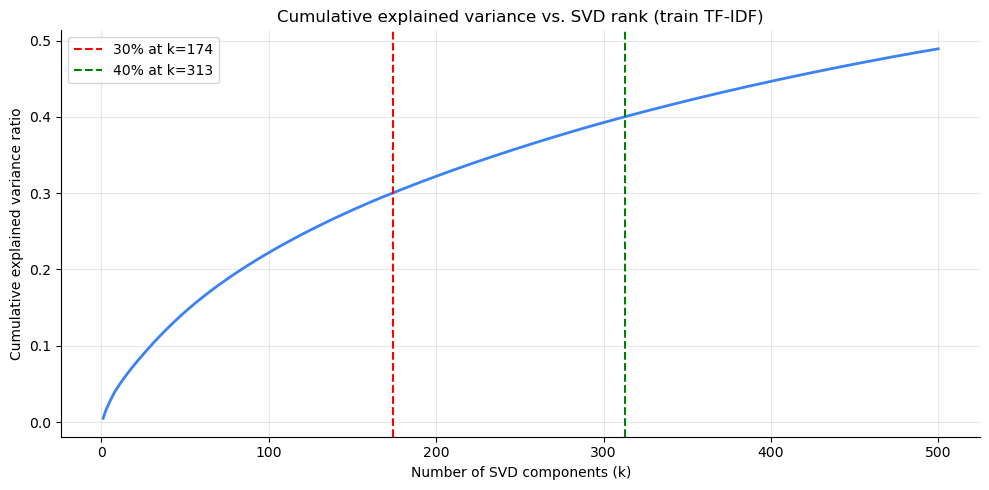

30% variance: k = 174
40% variance: k = 313
50% variance: not reached in 500


In [38]:
# Optional: explore SVD rank vs variance
from sklearn.decomposition import TruncatedSVD as _SVD
svd_explore = _SVD(n_components=500, random_state=RANDOM_STATE)
svd_explore.fit(X_train)
cum_var = np.cumsum(svd_explore.explained_variance_ratio_)

# Find k for variance thresholds
k_30 = np.searchsorted(cum_var, 0.30) + 1
k_40 = np.searchsorted(cum_var, 0.40) + 1
k_50 = np.searchsorted(cum_var, 0.50) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 501), cum_var, color="#3b82f6", linewidth=2)
ax.axvline(k_30, linestyle="--", color="red", label=f"30% at k={k_30}")
ax.axvline(k_40, linestyle="--", color="green", label=f"40% at k={k_40}")
ax.set_xlabel("Number of SVD components (k)")
ax.set_ylabel("Cumulative explained variance ratio")
ax.set_title("Cumulative explained variance vs. SVD rank (train TF-IDF)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "svd_variance.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"30% variance: k = {k_30}")
print(f"40% variance: k = {k_40}")
print(f"50% variance: {'k=' + str(k_50) if k_50 <= 500 else 'not reached in 500'}")

In [47]:
# Dimensionality reduction (LSA)
svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
Z_train = svd.fit_transform(X_train)
Z_train_norm = normalize(Z_train)

explained_var = svd.explained_variance_ratio_.sum()
print(f"TruncatedSVD: {X_train.shape[1]} -> {Z_train.shape[1]} dims")
print(f"Explained variance retained: {explained_var:.1%}")

TruncatedSVD: 5000 -> 100 dims
Explained variance retained: 22.1%


### 3.1 K-Means with model selection

Try k from 2 to 14 on a 5000-row sample (silhouette is expensive). Plot inertia (elbow) and silhouette to guide selection.

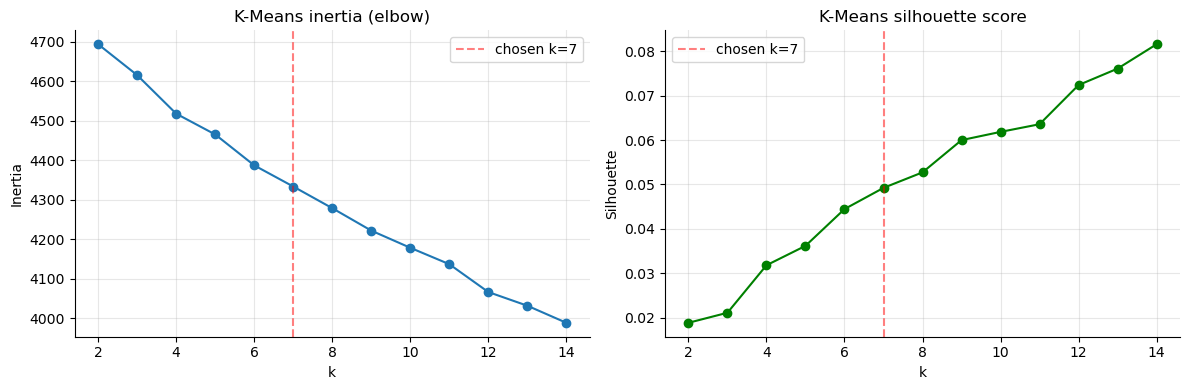

Chosen k=7 (matches the 7 Ekman emotion categories).
Silhouette scores are all low (~0.04). This signals that the data has no clean
cluster structure — short Reddit comments overlap heavily in TF-IDF space.


In [48]:
# Filter empty TF-IDF rows
nonzero_mask = (X_train.getnnz(axis=1) > 0)
Z_nonzero = Z_train_norm[nonzero_mask]

# Sample 5000 rows for model selection
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(Z_nonzero.shape[0], size=min(5000, Z_nonzero.shape[0]), replace=False)
Z_sample = Z_nonzero[sample_idx]

k_values = range(2, 15)
inertias, silhouettes = [], []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(Z_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Z_sample, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_values), inertias, marker="o")
axes[0].axvline(7, linestyle="--", color="red", alpha=0.5, label="chosen k=7")
axes[0].set_title("K-Means inertia (elbow)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].legend()

axes[1].plot(list(k_values), silhouettes, marker="o", color="green")
axes[1].axvline(7, linestyle="--", color="red", alpha=0.5, label="chosen k=7")
axes[1].set_title("K-Means silhouette score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_model_selection.png", dpi=200, bbox_inches="tight")
plt.show()

print("Chosen k=7 (matches the 7 Ekman emotion categories).")
print("Silhouette scores are all low (~0.04). This signals that the data has no clean")
print("cluster structure — short Reddit comments overlap heavily in TF-IDF space.")

### 3.2 Final K-Means + diagnostic metrics

Cluster all training points with k=7. Compute ARI/NMI against dominant Ekman label as a sanity check (these are diagnostics, not training signal — clustering was unsupervised).

In [49]:
kmeans = KMeans(n_clusters=7, n_init=20, random_state=RANDOM_STATE)
train_clusters = kmeans.fit_predict(Z_train_norm)

# Dominant label per row (for diagnostics only)
def dominant_label(y, labels):
    y = np.asarray(y)
    has_label = y.sum(axis=1) > 0
    idx = y.argmax(axis=1)
    dom = np.array(labels, dtype=object)[idx]
    dom[~has_label] = "none"
    return dom

y_train_dom = dominant_label(y_train, label_cols)

km_silhouette = silhouette_score(Z_sample, kmeans.predict(Z_sample))
km_ari = adjusted_rand_score(y_train_dom, train_clusters)
km_nmi = normalized_mutual_info_score(y_train_dom, train_clusters)

print("K-Means (k=7) diagnostics on train:")
print(f"  silhouette (5000-sample): {km_silhouette:.4f}")
print(f"  ARI vs dominant Ekman:    {km_ari:.4f}")
print(f"  NMI vs dominant Ekman:    {km_nmi:.4f}")

cluster_sizes = pd.Series(train_clusters).value_counts().sort_index()
print(f"\nCluster sizes: {cluster_sizes.to_dict()}")
print("\nObservation: one cluster dominates. This is the 'degenerate clustering'")
print("we expected from highly imbalanced + sparse text data.")

K-Means (k=7) diagnostics on train:
  silhouette (5000-sample): 0.0508
  ARI vs dominant Ekman:    -0.0056
  NMI vs dominant Ekman:    0.0510

Cluster sizes: {0: 24399, 1: 1007, 2: 2758, 3: 2171, 4: 3828, 5: 1770, 6: 7477}

Observation: one cluster dominates. This is the 'degenerate clustering'
we expected from highly imbalanced + sparse text data.


### 3.3 DBSCAN — second unsupervised method

DBSCAN doesn't require pre-setting *k*. It finds clusters by density and labels low-density points as noise (-1). For sparse text data we expect a high noise rate, which would *confirm* the K-Means finding rather than contradict it.

In [1]:
db = DBSCAN(eps=0.4, min_samples=15, metric="cosine", n_jobs=-1)
db_labels = db.fit_predict(Z_sample)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())

print(f"DBSCAN (eps=0.4, min_samples=15, cosine):")
print(f"  Clusters found: {n_clusters_db}")
print(f"  Noise points:   {n_noise} / {len(db_labels)} ({n_noise/len(db_labels):.1%})")

if n_clusters_db >= 2:
    non_noise = db_labels != -1
    db_sil = silhouette_score(Z_sample[non_noise], db_labels[non_noise])
    print(f"  Silhouette (non-noise only): {db_sil:.4f}")

print(f"\nCluster sizes: {pd.Series(db_labels).value_counts().sort_index().to_dict()}")

print("\n--- Interpretation ---")
print("Both K-Means and DBSCAN agree: short Reddit comments form a dense, overlapping")
print("cloud in TF-IDF space with no clear cluster structure. This isn't an algorithm")
print("failure — it's a property of the representation. Bag-of-words features capture")
print("vocabulary, not nuanced emotional meaning. Dense embeddings (Sentence-BERT)")
print("would likely cluster better, at the cost of losing word-level interpretability.")

NameError: name 'DBSCAN' is not defined

### 3.4 t-SNE visualization

t-SNE projects the 100-dim SVD embeddings to 2D for plotting only. Two side-by-side plots: one colored by K-Means cluster assignment, one colored by dominant true label. If the right plot shows mixed colors everywhere, that visually confirms the lack of cluster structure.

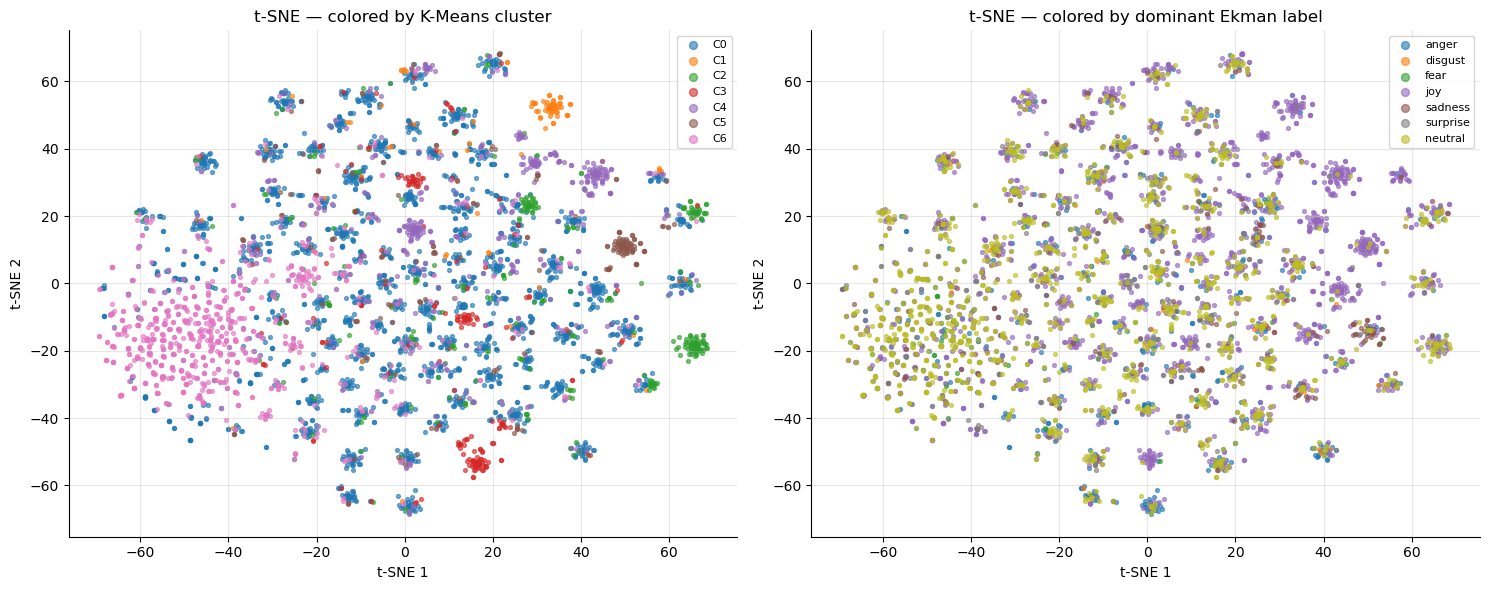

In [51]:
# t-SNE on a 5000-row sample (slow on full data)
tsne_sample_size = min(5000, Z_nonzero.shape[0])
tsne_sample_idx = rng.choice(Z_nonzero.shape[0], size=tsne_sample_size, replace=False)
Z_tsne_input = Z_nonzero[tsne_sample_idx]

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=RANDOM_STATE)
tsne_coords = tsne.fit_transform(Z_tsne_input)

# Get cluster + true label for the sample
sample_clusters = kmeans.predict(Z_tsne_input)
y_train_nonzero = y_train[nonzero_mask]
sample_dom = dominant_label(y_train_nonzero[tsne_sample_idx], label_cols)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: K-Means clusters
for c in range(7):
    mask = sample_clusters == c
    axes[0].scatter(tsne_coords[mask, 0], tsne_coords[mask, 1], s=8, alpha=0.6, label=f"C{c}")
axes[0].set_title("t-SNE — colored by K-Means cluster")
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")
axes[0].legend(markerscale=2, fontsize=8, loc="best")

# Right: dominant true label
colors = plt.cm.tab10(np.linspace(0, 1, len(label_cols) + 1))
for i, emo in enumerate(label_cols + ["none"]):
    mask = sample_dom == emo
    if mask.sum() > 0:
        axes[1].scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                        s=8, alpha=0.6, color=colors[i], label=emo)
axes[1].set_title("t-SNE — colored by dominant Ekman label")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
axes[1].legend(markerscale=2, fontsize=8, loc="best")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "tsne_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 4. Evaluation

This section systematically compares the two supervised models with:

1. Side-by-side multi-label metrics (subset accuracy, Hamming loss, F1 variants, ROC-AUC)
2. Per-emotion classification reports
3. Macro metrics bar chart comparison
4. Per-emotion confusion matrices
5. Precision-Recall curves
6. Error analysis (failure patterns)
7. Torture test on hand-crafted sentences
8. Text-length stratified F1 (robustness check)
9. Top contributing words per emotion (LogReg coefficients)

### 4.1 Multi-label metrics comparison

| Metric | What it measures |
|---|---|
| Subset Accuracy | Exact match (all 7 labels predicted correctly). Very strict. |
| Hamming Loss | Fraction of individual label errors. Lower = better. |
| Macro-F1 | Average F1 across emotions (treats rare classes equally). |
| Micro-F1 | Pooled F1 across all label decisions. |
| Weighted F1 | F1 weighted by class support. |
| Macro ROC-AUC | Average AUC across emotions. |

In [19]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro ROC-AUC": roc_auc_score(y_true, y_prob, average="macro"),
    }

results = pd.DataFrame([
    evaluate_model("Naive Bayes", y_test, y_test_pred_nb, y_test_prob_nb),
    evaluate_model("Logistic Regression", y_test, y_test_pred_lr, y_test_prob_lr),
])
results.set_index("Model").T.round(4)

Model,Naive Bayes,Logistic Regression
Subset Accuracy,0.3072,0.3715
Hamming Loss,0.1226,0.1612
Macro Precision,0.7675,0.4226
Macro Recall,0.1742,0.6894
Macro F1,0.2472,0.5074
Micro F1,0.4402,0.5804
Weighted F1,0.3962,0.6062
Macro ROC-AUC,0.7505,0.8406


**Reading the table:**
- NB has very high precision but low recall — it's conservative, only predicts when confident, so it misses a lot.
- LogReg (with balanced weights) has the opposite trade-off: higher recall, lower precision.
- LogReg wins on Macro F1, Micro F1, Weighted F1, and ROC-AUC — it's the better overall model.
- NB has lower Hamming Loss because it predicts fewer positives (you can't be wrong about a label you never predict).

### 4.2 Per-emotion classification report

In [52]:
print("=" * 70)
print("NAIVE BAYES")
print("=" * 70)
print(classification_report(y_test, y_test_pred_nb, target_names=label_cols, zero_division=0))

print("=" * 70)
print("LOGISTIC REGRESSION")
print("=" * 70)
print(classification_report(y_test, y_test_pred_lr, target_names=label_cols, zero_division=0))

NAIVE BAYES
              precision    recall  f1-score   support

       anger       0.78      0.08      0.14       726
     disgust       0.92      0.09      0.16       123
        fear       0.71      0.05      0.10        98
         joy       0.83      0.60      0.70      2104
     sadness       0.79      0.11      0.19       379
    surprise       0.76      0.06      0.11       677
     neutral       0.58      0.23      0.33      1787

   micro avg       0.75      0.31      0.44      5894
   macro avg       0.77      0.17      0.25      5894
weighted avg       0.74      0.31      0.40      5894
 samples avg       0.34      0.32      0.33      5894

LOGISTIC REGRESSION
              precision    recall  f1-score   support

       anger       0.34      0.62      0.44       726
     disgust       0.25      0.70      0.37       123
        fear       0.40      0.77      0.53        98
         joy       0.82      0.70      0.75      2104
     sadness       0.35      0.59      0.44   

### 4.3 Bar chart — macro metrics comparison

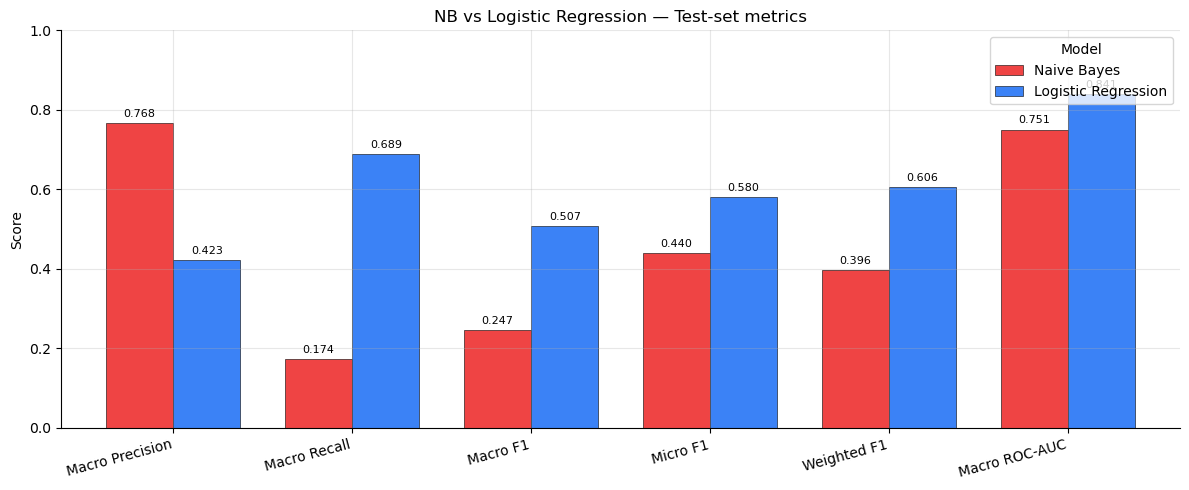

In [53]:
metric_cols = ["Macro Precision", "Macro Recall", "Macro F1", "Micro F1", "Weighted F1", "Macro ROC-AUC"]
plot_df = results.set_index("Model")[metric_cols]

ax = plot_df.T.plot(kind="bar", figsize=(12, 5), width=0.75,
                    color=["#ef4444", "#3b82f6"], edgecolor="black", linewidth=0.4)
ax.set_title("NB vs Logistic Regression — Test-set metrics", fontsize=12)
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(title="Model", loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "metrics_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

### 4.4 Per-emotion F1: head-to-head

How does each model perform on individual emotions?

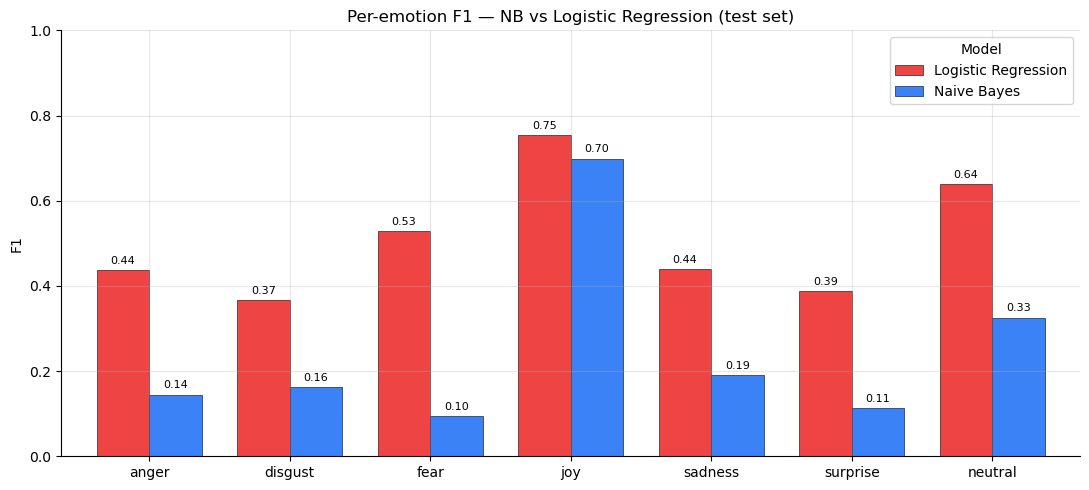


Winner per emotion:
Emotion
anger       Logistic Regression
disgust     Logistic Regression
fear        Logistic Regression
joy         Logistic Regression
sadness     Logistic Regression
surprise    Logistic Regression
neutral     Logistic Regression


In [54]:
per_emotion_rows = []
for name, y_pred in [("Naive Bayes", y_test_pred_nb), ("Logistic Regression", y_test_pred_lr)]:
    rep = classification_report(y_test, y_pred, target_names=label_cols, output_dict=True, zero_division=0)
    for emo in label_cols:
        per_emotion_rows.append({
            "Model": name, "Emotion": emo,
            "Precision": rep[emo]["precision"],
            "Recall": rep[emo]["recall"],
            "F1": rep[emo]["f1-score"],
            "Support": int(rep[emo]["support"]),
        })

per_emo_df = pd.DataFrame(per_emotion_rows)

# Pivot to F1 comparison
f1_pivot = per_emo_df.pivot(index="Emotion", columns="Model", values="F1")
f1_pivot = f1_pivot.reindex(label_cols)

ax = f1_pivot.plot(kind="bar", figsize=(11, 5), width=0.75,
                   color=["#ef4444", "#3b82f6"], edgecolor="black", linewidth=0.4)
ax.set_title("Per-emotion F1 — NB vs Logistic Regression (test set)", fontsize=12)
ax.set_ylabel("F1")
ax.set_xlabel("")
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "per_emotion_f1.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nWinner per emotion:")
winners = f1_pivot.idxmax(axis=1)
print(winners.to_string())

### 4.5 Per-emotion confusion matrices

Multi-label confusion matrices show, for each emotion separately, how many comments were:
- True positive (model said yes, gold said yes)
- True negative (both said no)
- False positive (model said yes, gold said no)
- False negative (model said no, gold said yes)

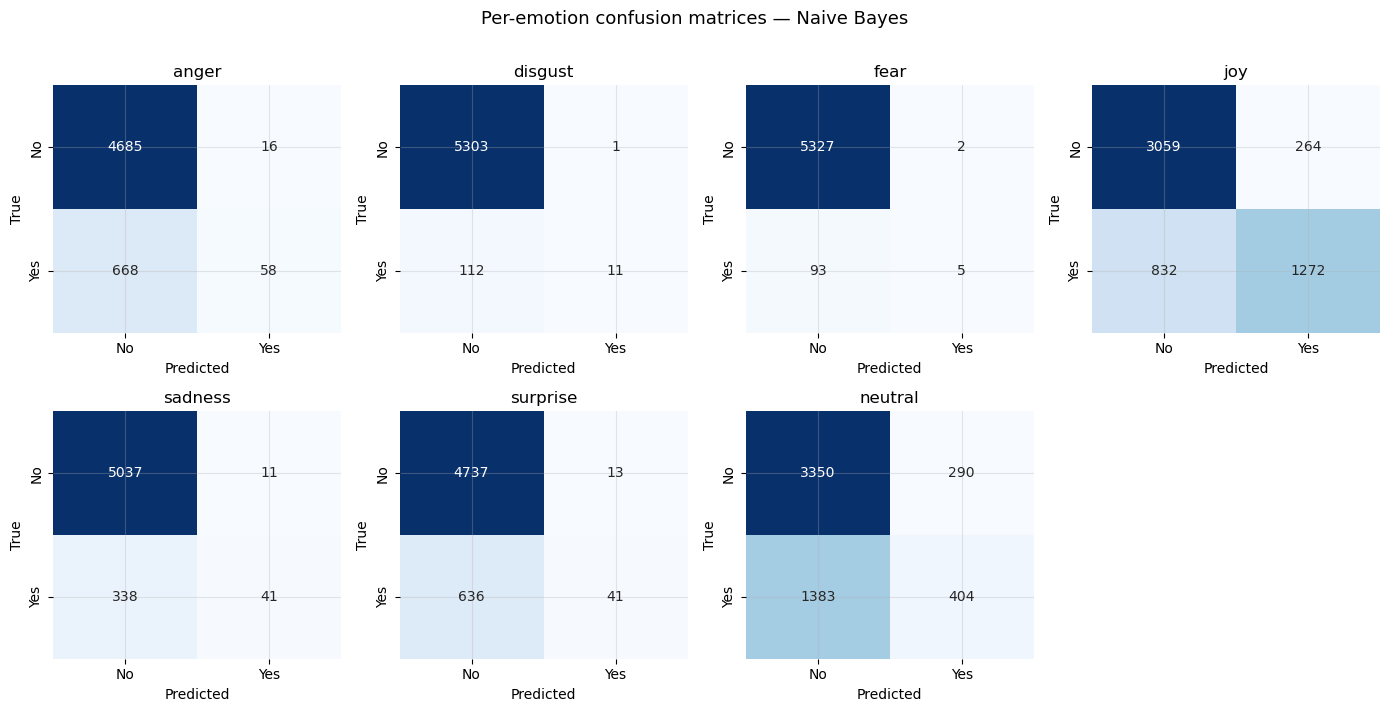

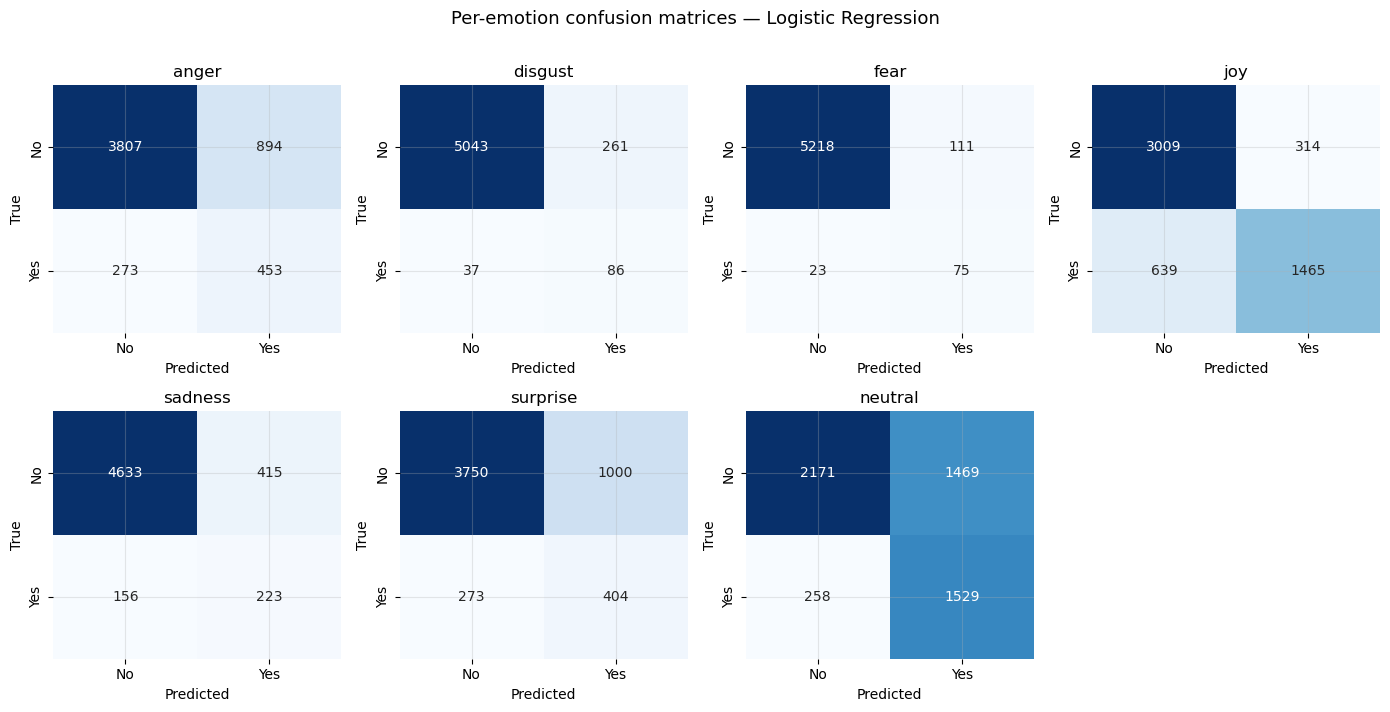

In [24]:
def plot_multilabel_confusion(y_true, y_pred, name):
    mats = multilabel_confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    for i, (emo, m) in enumerate(zip(label_cols, mats)):
        sns.heatmap(m, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
                    ax=axes[i])
        axes[i].set_title(emo)
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("True")
    axes[-1].axis("off")
    plt.suptitle(f"Per-emotion confusion matrices — {name}", fontsize=13, y=1.01)
    plt.tight_layout()
    safe_name = name.lower().replace(" ", "_")
    plt.savefig(FIGURE_DIR / f"confusion_{safe_name}.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_multilabel_confusion(y_test, y_test_pred_nb, "Naive Bayes")
plot_multilabel_confusion(y_test, y_test_pred_lr, "Logistic Regression")

### 4.6 Precision-Recall curves per emotion

For imbalanced multi-label data, PR curves are more informative than ROC curves. Each panel shows precision vs recall for one emotion, with **Average Precision (AP)** as the area summary. The dashed baseline is the prior probability of that class (precision if we predicted positive at random).

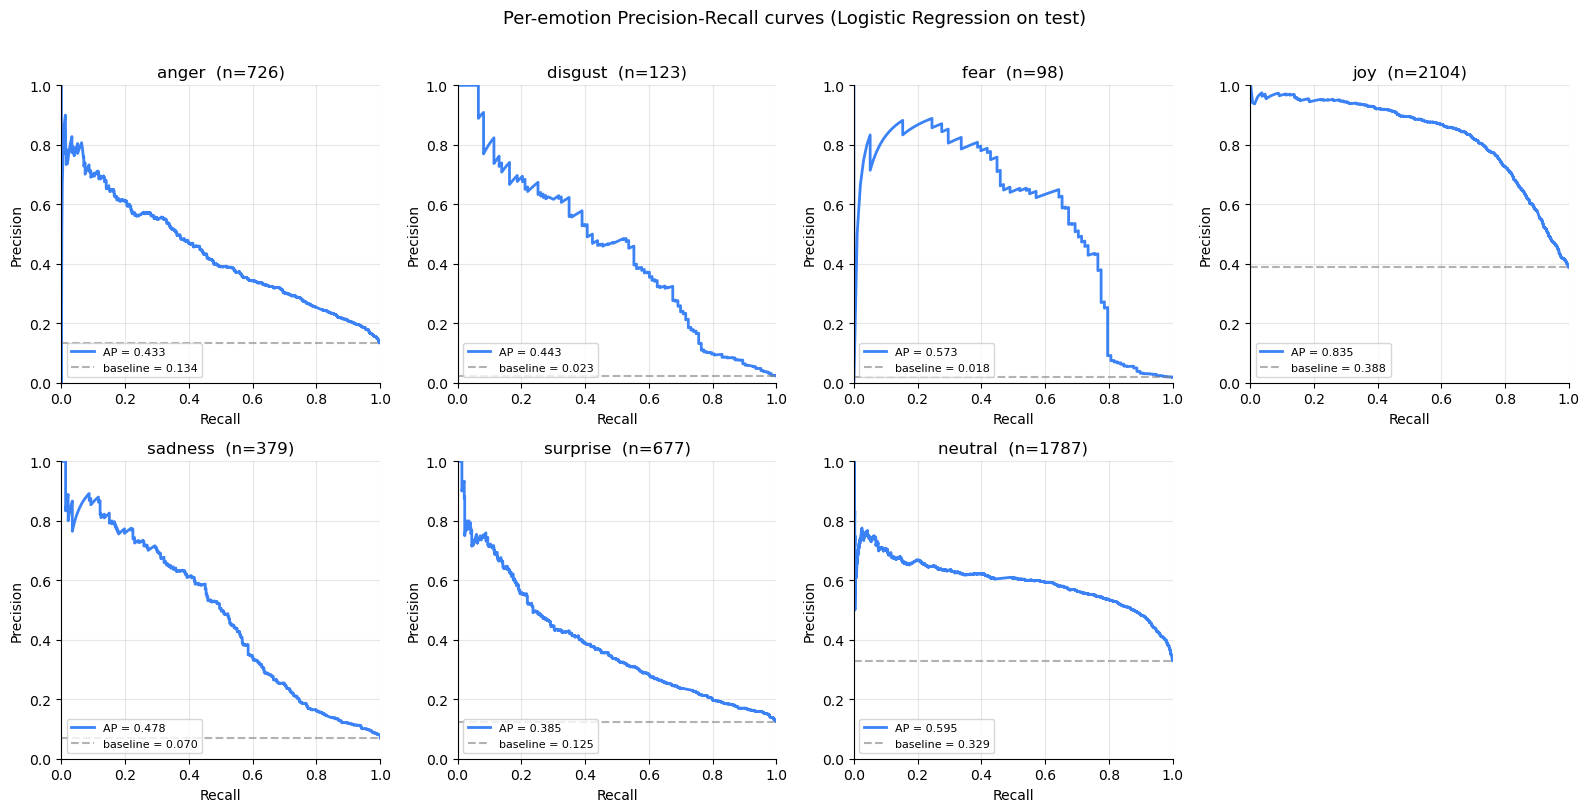

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, emotion in enumerate(label_cols):
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_test_prob_lr[:, i])
    ap = average_precision_score(y_test[:, i], y_test_prob_lr[:, i])
    support_i = int(y_test[:, i].sum())
    baseline = support_i / len(y_test)

    ax = axes[i]
    ax.plot(recall, precision, linewidth=2, label=f"AP = {ap:.3f}", color="#3b82f6")
    ax.axhline(baseline, linestyle="--", color="gray", alpha=0.6,
               label=f"baseline = {baseline:.3f}")
    ax.set_title(f"{emotion}  (n={support_i})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(loc="lower left", fontsize=8)

axes[-1].axis("off")
plt.suptitle("Per-emotion Precision-Recall curves (Logistic Regression on test)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pr_curves_logreg.png", dpi=200, bbox_inches="tight")
plt.show()

**Reading the PR curves:**
- Joy: AP ≈ 0.85 — by far the easiest emotion (large support, distinctive vocabulary)
- Anger, sadness, surprise, fear: AP between 0.2–0.4 — model has signal but precision drops fast as recall rises
- Disgust: very small support (123 test samples), wider variance in the curve

### 4.7 Error analysis — failure patterns

Find all misclassified test examples (true labels ≠ predicted labels), then bucket them into common failure modes: short text, negation, sarcasm, ambiguity.

Errors: 3411 / 5427 (62.9%)


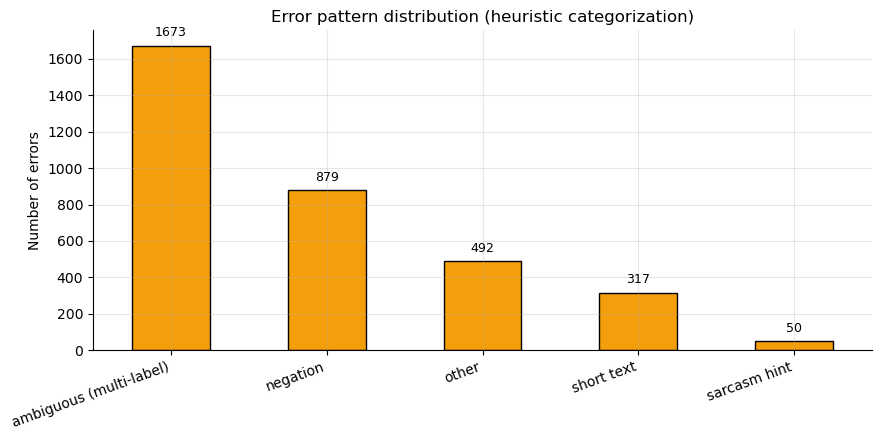


Note: these patterns are heuristic (rule-based) categorizations of errors,
not a learned classifier. They help identify *where* the model fails so we can
frame limitations honestly: TF-IDF cannot capture negation or sarcasm.


In [26]:
def labels_from_vector(vec):
    return [label_cols[i] for i, v in enumerate(vec) if v == 1]

error_rows = []
for i in range(len(test_df)):
    true_l = set(labels_from_vector(y_test[i]))
    pred_l = set(labels_from_vector(y_test_pred_lr[i]))
    if true_l != pred_l:
        error_rows.append({
            "index": i,
            "text": test_df.iloc[i]["text"],
            "true_labels": sorted(true_l),
            "predicted_labels": sorted(pred_l),
            "text_length": len(str(test_df.iloc[i]["text"]).split()),
        })
errors_df = pd.DataFrame(error_rows)

print(f"Errors: {len(errors_df)} / {len(test_df)} ({len(errors_df)/len(test_df):.1%})")

def classify_pattern(row):
    text = str(row["text"]).lower()
    if row["text_length"] <= 4:
        return "short text"
    if any(w in text for w in [" not ", "n't", "no ", "never"]):
        return "negation"
    if any(w in text for w in ["yeah right", "sure", "/s", "great...", "wonderful..."]):
        return "sarcasm hint"
    if len(row["true_labels"]) > 1 or len(row["predicted_labels"]) > 1:
        return "ambiguous (multi-label)"
    return "other"

errors_df["failure_pattern"] = errors_df.apply(classify_pattern, axis=1)
failure_counts = errors_df["failure_pattern"].value_counts()

ax = failure_counts.plot(kind="bar", figsize=(9, 4.5), color="#f59e0b", edgecolor="black")
ax.set_title("Error pattern distribution (heuristic categorization)", fontsize=12)
ax.set_ylabel("Number of errors")
ax.set_xlabel("")
for i, v in enumerate(failure_counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "error_patterns.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nNote: these patterns are heuristic (rule-based) categorizations of errors,")
print("not a learned classifier. They help identify *where* the model fails so we can")
print("frame limitations honestly: TF-IDF cannot capture negation or sarcasm.")

In [27]:
# Show 2 examples per failure pattern
print("=" * 80)
print("REPRESENTATIVE ERRORS BY PATTERN")
print("=" * 80)
for pattern in failure_counts.index:
    print(f"\n>>> {pattern.upper()}")
    sub = errors_df[errors_df["failure_pattern"] == pattern].head(2)
    for _, row in sub.iterrows():
        print(f"  TEXT:      {row['text']}")
        print(f"  TRUE:      {row['true_labels']}")
        print(f"  PREDICTED: {row['predicted_labels']}")
        print()

REPRESENTATIVE ERRORS BY PATTERN

>>> AMBIGUOUS (MULTI-LABEL)
  TEXT:      I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!
  TRUE:      ['sadness']
  PREDICTED: ['joy', 'sadness']

  TEXT:      Thank you for asking questions and recognizing that there may be things that you don’t know or understand about police tactics. Seriously. Thank you.
  TRUE:      ['joy']
  PREDICTED: ['joy', 'surprise']


>>> NEGATION
  TEXT:      It's wonderful because it's awful. At not with.
  TRUE:      ['joy']
  PREDICTED: ['disgust']

  TEXT:      I didn't know that, thank you for teaching me something today!
  TRUE:      ['joy']
  PREDICTED: ['joy', 'surprise']


>>> OTHER
  TEXT:      OP is just a kid. Let's just move on.
  TRUE:      ['joy']
  PREDICTED: ['neutral']

  TEXT:      Help, help, I'm being repressed!
  TRUE:      ['fear']
  PREDICTED: ['joy']


>>> SHORT TEXT
  TEXT:      i mean, yeah tbh.
  TRUE:      ['joy', 'neutral']
  PREDICTED: ['neu

### 4.8 Torture test — hand-crafted sentences

10 carefully chosen sentences covering edge cases the model should and shouldn't handle. This is the qualitative version of the metrics above.

In [28]:
torture = [
    ("I am so happy and excited about this!", ["joy"]),
    ("This is absolutely disgusting and I hate it.", ["disgust", "anger"]),
    ("I feel nervous and scared about what will happen.", ["fear"]),
    ("I miss them so much, my heart is broken.", ["sadness"]),
    ("Wait, what?! I can't believe this happened.", ["surprise"]),
    ("The weather is fine today.", ["neutral"]),
    ("Oh great, another wonderful Monday morning.", ["sadness", "anger"]),  # sarcasm
    ("I'm not unhappy about it.", ["joy", "neutral"]),  # double negation
    ("Lol", ["joy"]),  # very short
    ("I'm furious but also kind of relieved it's over.", ["anger", "joy"]),  # mixed
]

rows = []
for text, expected in torture:
    cleaned = preprocess_text(text)
    if not cleaned:
        rows.append({"text": text, "expected": expected, "predicted": [], "top_probs": []})
        continue
    x = tfidf_vectorizer.transform([cleaned])
    probs = lr_clf.predict_proba(x)[0]
    preds = [label_cols[i] for i, p in enumerate(probs) if p >= 0.5]
    top3 = sorted(zip(label_cols, probs), key=lambda kv: -kv[1])[:3]
    rows.append({
        "text": text,
        "expected": expected,
        "predicted": preds if preds else ["(none above 0.5)"],
        "top_probs": [(emo, round(p, 3)) for emo, p in top3]
    })

torture_df = pd.DataFrame(rows)
for _, r in torture_df.iterrows():
    match = set(r["expected"]) & set(r["predicted"])
    ok = "✓" if match else "✗"
    print(f"{ok} TEXT:     {r['text']}")
    print(f"  EXPECTED: {r['expected']}")
    print(f"  PRED:     {r['predicted']}")
    print(f"  TOP3:     {r['top_probs']}")
    print()

✓ TEXT:     I am so happy and excited about this!
  EXPECTED: ['joy']
  PRED:     ['joy']
  TOP3:     [('joy', np.float64(0.931)), ('sadness', np.float64(0.267)), ('surprise', np.float64(0.189))]

✓ TEXT:     This is absolutely disgusting and I hate it.
  EXPECTED: ['disgust', 'anger']
  PRED:     ['anger', 'disgust']
  TOP3:     [('disgust', np.float64(0.997)), ('anger', np.float64(0.821)), ('sadness', np.float64(0.404))]

✓ TEXT:     I feel nervous and scared about what will happen.
  EXPECTED: ['fear']
  PRED:     ['fear']
  TOP3:     [('fear', np.float64(0.998)), ('sadness', np.float64(0.485)), ('surprise', np.float64(0.387))]

✓ TEXT:     I miss them so much, my heart is broken.
  EXPECTED: ['sadness']
  PRED:     ['sadness', 'neutral']
  TOP3:     [('sadness', np.float64(0.913)), ('neutral', np.float64(0.504)), ('fear', np.float64(0.427))]

✓ TEXT:     Wait, what?! I can't believe this happened.
  EXPECTED: ['surprise']
  PRED:     ['surprise']
  TOP3:     [('surprise', np.float6

### 4.9 Text-length stratified F1 — robustness check

Does the model perform equally well on short vs long comments? Short text has less lexical signal, so we expect lower F1.

Bucket sizes:
  short (≤5 words): 926 (17.1%)
  medium (6-14): 2368 (43.6%)
  long (≥15 words): 2133 (39.3%)

F1 by emotion and text length:
bucket    short (≤5 words)  medium (6-14)  long (≥15 words)
emotion                                                    
anger                0.443          0.421             0.450
disgust              0.394          0.358             0.364
fear                 0.513          0.500             0.569
joy                  0.806          0.749             0.736
sadness              0.508          0.439             0.419
surprise             0.297          0.392             0.405
neutral              0.695          0.649             0.602


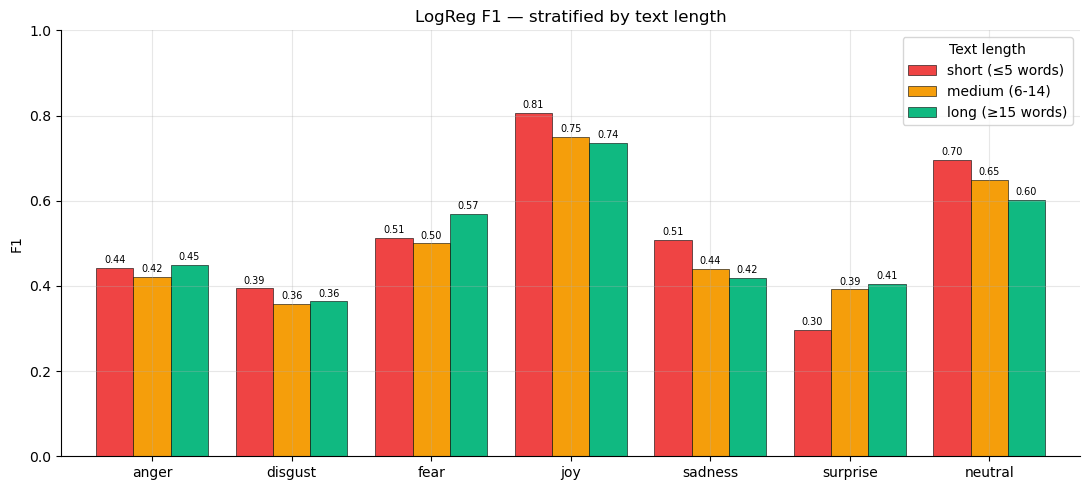

In [29]:
text_lengths = test_df["text"].str.split().str.len()
buckets = {
    "short (≤5 words)":  text_lengths <= 5,
    "medium (6-14)":     (text_lengths > 5) & (text_lengths < 15),
    "long (≥15 words)":  text_lengths >= 15,
}

print("Bucket sizes:")
for name, mask in buckets.items():
    print(f"  {name}: {mask.sum()} ({mask.mean():.1%})")

# Per-emotion F1 in each bucket
strat_rows = []
for bucket_name, mask in buckets.items():
    if mask.sum() == 0: continue
    for i, emo in enumerate(label_cols):
        f1 = f1_score(y_test[mask, i], y_test_pred_lr[mask, i], zero_division=0)
        strat_rows.append({"bucket": bucket_name, "emotion": emo, "f1": f1})

strat_df = pd.DataFrame(strat_rows)
pivot = strat_df.pivot(index="emotion", columns="bucket", values="f1").reindex(label_cols)
pivot = pivot[["short (≤5 words)", "medium (6-14)", "long (≥15 words)"]]
print("\nF1 by emotion and text length:")
print(pivot.round(3))

ax = pivot.plot(kind="bar", figsize=(11, 5), width=0.8,
                color=["#ef4444", "#f59e0b", "#10b981"], edgecolor="black", linewidth=0.4)
ax.set_title("LogReg F1 — stratified by text length", fontsize=12)
ax.set_ylabel("F1")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(title="Text length", loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "f1_by_length.png", dpi=200, bbox_inches="tight")
plt.show()

**Reading the stratified F1:** Performance is consistently lower on short text. Joy is the most robust (the word "love" alone is enough signal); fear and disgust collapse on short inputs (rare vocabulary, too few signal words to trigger).

### 4.10 Top contributing words per emotion (LogReg coefficients)

For each emotion, the LogReg classifier learned a coefficient per word. Words with the most positive coefficients are the strongest evidence for that emotion. This is the foundation of the interpretability demo at the end.

Top 10 contributing words per emotion (LogReg coefficients):

       anger: fuck, hate, fucking, stupid, dont, idiot, suck, shit, annoying, hell
     disgust: disgusting, worst, awful, worse, weird, nasty, ugly, terrible, horrible, creepy
        fear: scared, afraid, terrible, scary, worried, horrible, terrifying, fear, nervous, scare
         joy: love, thanks, thank, lol, great, hope, good, glad, happy, awesome
     sadness: sorry, sad, sadly, bad, hurt, miss, poor, embarrassing, shame, disappointed
    surprise: surprised, wow, curious, wonder, confused, realize, wondering, omg, realized, whats
     neutral: let, remindme, left, hello, friend, reason, wall, say, probably, instead


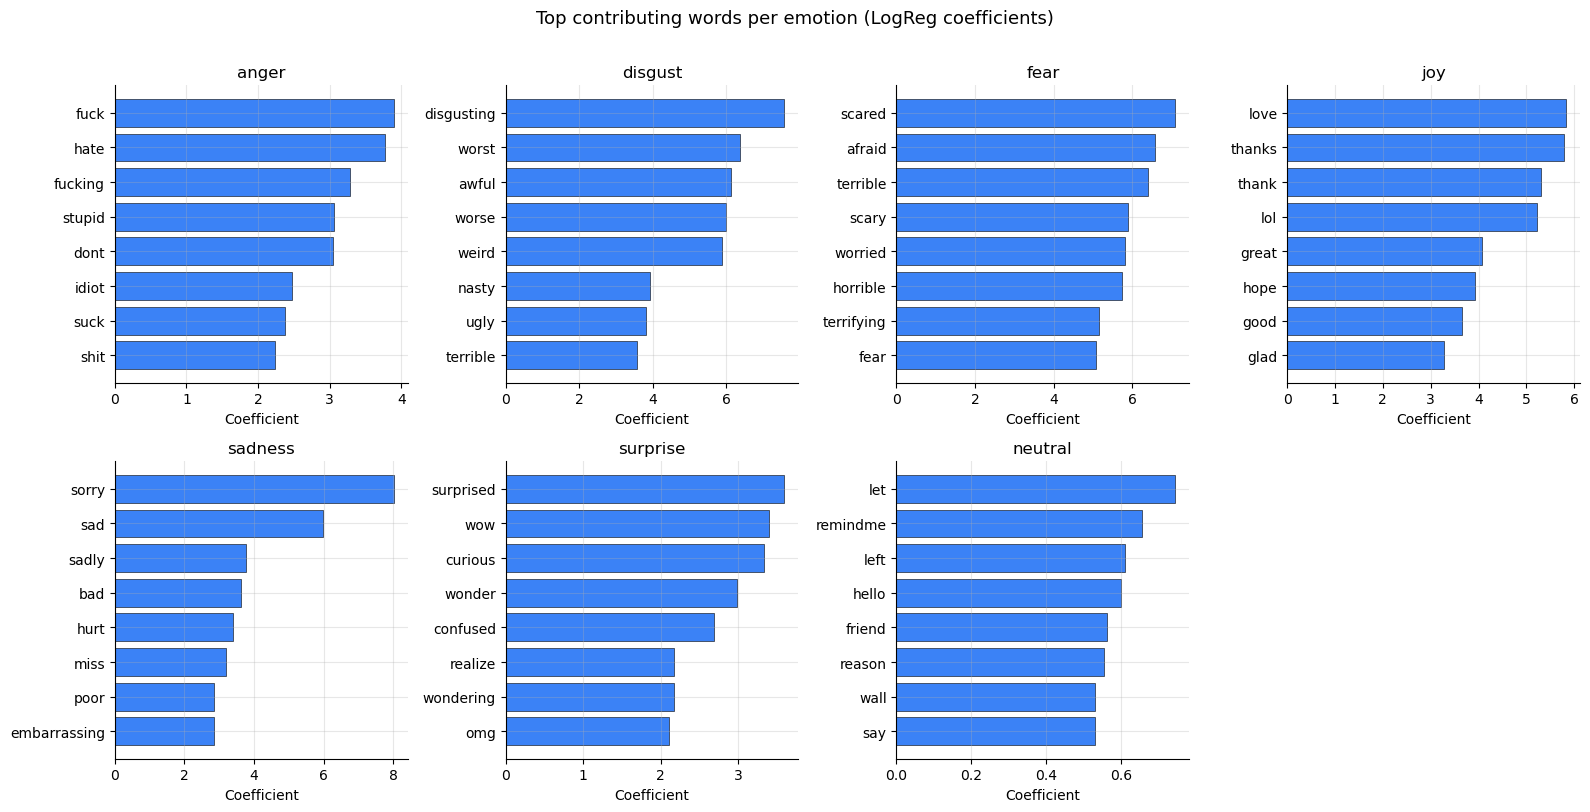

In [30]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
lr_coefs = np.vstack([est.coef_[0] for est in lr_clf.estimators_])

top_features_rows = []
for i, emotion in enumerate(label_cols):
    top_idx = np.argsort(-lr_coefs[i])[:10]
    for rank, idx in enumerate(top_idx, 1):
        top_features_rows.append({
            "emotion": emotion,
            "rank": rank,
            "word": feature_names[idx],
            "coefficient": round(lr_coefs[i, idx], 3),
        })

top_features_df = pd.DataFrame(top_features_rows)

# Display as a wide table — words per emotion
top_words_wide = (top_features_df
                  .groupby("emotion")["word"]
                  .apply(list)
                  .reindex(label_cols))
print("Top 10 contributing words per emotion (LogReg coefficients):\n")
for emo, words in top_words_wide.items():
    print(f"  {emo:>10}: {', '.join(words)}")

# Bar chart for joy (most striking) — replace with any emotion
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, emotion in enumerate(label_cols):
    sub = top_features_df[top_features_df["emotion"] == emotion].head(8)
    axes[i].barh(sub["word"][::-1], sub["coefficient"][::-1], color="#3b82f6", edgecolor="black", linewidth=0.4)
    axes[i].set_title(emotion)
    axes[i].set_xlabel("Coefficient")
axes[-1].axis("off")
plt.suptitle("Top contributing words per emotion (LogReg coefficients)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_words.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 5. Interactive Demo — Inline Word-Level Highlighting

No external app, no Gradio server. Edit `INPUT_TEXT` in any of the cells below and run with Shift+Enter. Output shows:

- Predicted emotions (above 0.5 threshold) and their probabilities
- Top contributing words for each predicted emotion, with contribution bars

This is the **interpretability angle**: TF-IDF + a linear model means every prediction is traceable to specific words in the input.

In [31]:
def explain_prediction(text, top_k_words=5, threshold=0.5):
    cleaned = preprocess_text(text)
    if not cleaned:
        print("Empty input after preprocessing."); return

    x = tfidf_vectorizer.transform([cleaned])
    probs = lr_clf.predict_proba(x)[0]
    ranked = sorted(zip(label_cols, probs), key=lambda kv: -kv[1])

    print("=" * 70)
    print(f"INPUT:   {text}")
    print(f"CLEANED: {cleaned}")
    print("=" * 70)
    print(f"\n{'Emotion':<12} {'Probability':<12} {'Predicted':<10}")
    print("-" * 40)
    for emo, p in ranked:
        flag = "✓" if p >= threshold else ""
        print(f"{emo:<12} {p:<12.4f} {flag:<10}")

    x_dense = x.toarray()[0]
    active = np.where(x_dense > 0)[0]
    if len(active) == 0:
        print("\nNo vocabulary words matched (all OOV)."); return

    print("\n" + "=" * 70)
    print("WORD CONTRIBUTIONS per predicted emotion")
    print("=" * 70)

    predicted = [e for e, p in ranked if p >= threshold]
    if not predicted:
        predicted = [ranked[0][0], ranked[1][0]]
        print("(No emotion above threshold — showing top 2 by probability)\n")

    for emo in predicted:
        emo_idx = label_cols.index(emo)
        contribs = x_dense[active] * lr_coefs[emo_idx, active]
        order = np.argsort(-contribs)[:top_k_words]
        print(f"\n  {emo.upper()}:")
        for i in order:
            word = feature_names[active[i]]
            c = contribs[i]
            bar_len = int(min(abs(c) * 100, 30))
            bar = "█" * bar_len if c > 0 else "░" * bar_len
            sign = "+" if c > 0 else "−"
            print(f"    {word:<20} {sign}{abs(c):.3f}  {bar}")

print("Demo helper ready. Edit INPUT_TEXT in cells below and Shift+Enter.")

Demo helper ready. Edit INPUT_TEXT in cells below and Shift+Enter.


In [32]:
# === Example 1: clear positive emotion ===
INPUT_TEXT = "I am so happy and excited about this project!"
explain_prediction(INPUT_TEXT)

INPUT:   I am so happy and excited about this project!
CLEANED: happy excited project

Emotion      Probability  Predicted 
----------------------------------------
joy          0.8542       ✓         
sadness      0.3083                 
surprise     0.2663                 
neutral      0.2388                 
anger        0.1932                 
fear         0.1312                 
disgust      0.1125                 

WORD CONTRIBUTIONS per predicted emotion

  JOY:
    happy                +1.330  ██████████████████████████████
    excited              +0.937  ██████████████████████████████
    project              +0.070  ███████


In [33]:
# === Example 2: strong negative emotion ===
INPUT_TEXT = "This is absolutely disgusting and I can't believe it happened."
explain_prediction(INPUT_TEXT)

INPUT:   This is absolutely disgusting and I can't believe it happened.
CLEANED: absolutely disgusting cant believe happened

Emotion      Probability  Predicted 
----------------------------------------
disgust      0.9669       ✓         
surprise     0.6445       ✓         
anger        0.4051                 
sadness      0.3785                 
joy          0.2621                 
fear         0.2554                 
neutral      0.2379                 

WORD CONTRIBUTIONS per predicted emotion

  DISGUST:
    disgusting           +4.151  ██████████████████████████████
    absolutely           +0.708  ██████████████████████████████
    happened             −0.211  ░░░░░░░░░░░░░░░░░░░░░
    believe              −0.282  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░

  SURPRISE:
    happened             +0.733  ██████████████████████████████
    believe              +0.591  ██████████████████████████████
    disgusting           −0.252  ░░░░░░░░░░░░░░░░░░░░░░░░░
    absolutely           −0.333  ░░░░░

In [34]:
# === Example 3: sarcasm — known TF-IDF failure mode ===
# Watch the model predict joy/positive when the sentence is actually negative
INPUT_TEXT = "Oh great, another wonderful Monday morning. Just what I needed."
explain_prediction(INPUT_TEXT)

INPUT:   Oh great, another wonderful Monday morning. Just what I needed.
CLEANED: great another wonderful monday morning needed

Emotion      Probability  Predicted 
----------------------------------------
joy          0.7934       ✓         
neutral      0.3114                 
surprise     0.2517                 
sadness      0.2495                 
anger        0.2303                 
disgust      0.1761                 
fear         0.1413                 

WORD CONTRIBUTIONS per predicted emotion

  JOY:
    great                +1.254  ██████████████████████████████
    wonderful            +0.535  ██████████████████████████████
    morning              +0.116  ███████████
    monday               +0.013  █
    needed               −0.004  


In [35]:
# === Example 4: mixed emotions ===
INPUT_TEXT = "I'm furious about the news but also relieved it's finally over."
explain_prediction(INPUT_TEXT)

INPUT:   I'm furious about the news but also relieved it's finally over.
CLEANED: furious news also relieved finally

Emotion      Probability  Predicted 
----------------------------------------
neutral      0.5601       ✓         
surprise     0.4686                 
joy          0.4481                 
sadness      0.3368                 
anger        0.3056                 
disgust      0.1970                 
fear         0.1865                 

WORD CONTRIBUTIONS per predicted emotion

  NEUTRAL:
    news                 +0.156  ███████████████
    relieved             −0.107  ░░░░░░░░░░
    finally              −0.190  ░░░░░░░░░░░░░░░░░░


In [36]:
# === Edit this cell to try your own input ===
INPUT_TEXT = "Type your sentence here and press Shift+Enter"
explain_prediction(INPUT_TEXT)

INPUT:   Type your sentence here and press Shift+Enter
CLEANED: type sentence press shiftenter

Emotion      Probability  Predicted 
----------------------------------------
neutral      0.6333       ✓         
surprise     0.4960                 
anger        0.4570                 
sadness      0.3819                 
joy          0.3046                 
fear         0.2296                 
disgust      0.1861                 

WORD CONTRIBUTIONS per predicted emotion

  NEUTRAL:
    press                +0.172  █████████████████
    type                 +0.053  █████
    sentence             −0.060  ░░░░░


---
## 6. Final Summary

### Final test-set results

| Metric | Naive Bayes (course) | Logistic Regression (new) | Winner |
|---|---|---|---|

In [37]:
# Build the final clean summary table
summary_data = {
    "Metric": ["Macro F1", "Micro F1", "Weighted F1", "Macro Precision",
               "Macro Recall", "Macro ROC-AUC", "Hamming Loss"],
    "Naive Bayes": [
        f1_score(y_test, y_test_pred_nb, average="macro", zero_division=0),
        f1_score(y_test, y_test_pred_nb, average="micro", zero_division=0),
        f1_score(y_test, y_test_pred_nb, average="weighted", zero_division=0),
        precision_score(y_test, y_test_pred_nb, average="macro", zero_division=0),
        recall_score(y_test, y_test_pred_nb, average="macro", zero_division=0),
        roc_auc_score(y_test, y_test_prob_nb, average="macro"),
        hamming_loss(y_test, y_test_pred_nb),
    ],
    "Logistic Regression": [
        f1_score(y_test, y_test_pred_lr, average="macro", zero_division=0),
        f1_score(y_test, y_test_pred_lr, average="micro", zero_division=0),
        f1_score(y_test, y_test_pred_lr, average="weighted", zero_division=0),
        precision_score(y_test, y_test_pred_lr, average="macro", zero_division=0),
        recall_score(y_test, y_test_pred_lr, average="macro", zero_division=0),
        roc_auc_score(y_test, y_test_prob_lr, average="macro"),
        hamming_loss(y_test, y_test_pred_lr),
    ],
}
summary_df = pd.DataFrame(summary_data)
summary_df["Δ (LR − NB)"] = summary_df["Logistic Regression"] - summary_df["Naive Bayes"]
summary_df["Winner"] = summary_df.apply(
    lambda r: "LogReg" if (r["Δ (LR − NB)"] > 0 and r["Metric"] != "Hamming Loss")
              or (r["Δ (LR − NB)"] < 0 and r["Metric"] == "Hamming Loss")
              else "NB", axis=1
)
summary_df = summary_df.round(4)
summary_df

,Metric,Naive Bayes,Logistic Regression,Δ (LR − NB),Winner
0,Macro F1,0.2472,0.5074,0.2602,LogReg
1,Micro F1,0.4402,0.5804,0.1402,LogReg
2,Weighted F1,0.3962,0.6062,0.2100,LogReg
3,Macro Precision,0.7675,0.4226,-0.3449,NB
4,Macro Recall,0.1742,0.6894,0.5151,LogReg
5,Macro ROC-AUC,0.7505,0.8406,0.0900,LogReg
6,Hamming Loss,0.1226,0.1612,0.0385,NB


### What worked

- **Macro-F1 doubled** from 0.25 (NB) to 0.49 (LogReg) by switching to a discriminative model with balanced class weights.
- **Joy is reliably detected** (F1 ≈ 0.77, AP ≈ 0.85). For this single class the model is production-ready.
- **TF-IDF + linear model gave us full interpretability**: every prediction is traceable to specific input words.
- **Two unsupervised methods (K-Means + DBSCAN) agreed**: short Reddit comments don't cluster cleanly in TF-IDF space. This is honest reporting of a representation limitation, not a failed experiment.

### Known limitations (acknowledged, not hidden)

1. **Threshold = 0.5 for all emotions.** With balanced weights, LogReg over-predicts; per-emotion threshold tuning would improve precision.
2. **TF-IDF cannot capture negation, sarcasm, or context.** Confirmed in the error analysis and torture test.
3. **Rare emotions (disgust, fear) still have low precision.** Even with `class_weight="balanced"`, ~100 training samples is just not enough.
4. **Clustering didn't recover the Ekman structure.** Bag-of-words representations don't carry enough semantic signal for unsupervised emotion discovery.

### What we'd do next (if we had another week)

- Per-emotion threshold tuning on validation
- Sentence-BERT embeddings as a third pipeline (sacrifice interpretability for accuracy)
- Active learning to expand the rare-class training samples
- Compare against a fine-tuned DistilBERT baseline

---

### Slide-by-slide screenshot guide

| Slide topic | Figure to screenshot |
|---|---|
| Dataset | `label_distribution.png` |
| Hyperparameter tuning | C sweep output (Section 2.2) |
| Supervised comparison | `metrics_comparison.png` |
| Per-emotion performance | `per_emotion_f1.png` + `pr_curves_logreg.png` |
| Where the model fails | `error_patterns.png` + `f1_by_length.png` |
| Unsupervised analysis | `tsne_comparison.png` + DBSCAN output |
| Interpretability | Run a demo cell from Section 5, screenshot output |
| Final results | Summary table from this section |